# ATHENA CAMM Hackathon 01
## Boundary Detection + Atom Finding

**September 2026**

A scientific algorithm should not only work once. It should be **explainable, testable, fast, consistent, and robust**.

### Challenge 1 — Boundary Detection
- Dataset: **SiSb**
- Input: **12 HAADF-STEM images**
- Goal: detect the crystalline–amorphous boundary

### Challenge 2 — Atom Finding
- Dataset: **YBCO**
- Input: atomic-resolution STEM images
- Goal: return atomic-column coordinates

All helper functions are kept in:

```text
utils.py
```

The notebook stays focused on the two functions you are asked to improve.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_16_11092026/boundary_detection.ipynb)

## 1. Setup

In [1]:
#%pip install -q pyTEMlib ipympl utils

In [2]:
# # Download only the files needed for this challenge
# !git clone -q --filter=blob:none --no-checkout -b k4my4r \
#     https://github.com/kbarakati/athena_camm_hackathon.git athena

# %cd athena
# !git sparse-checkout init --cone
# !git sparse-checkout set docs/day_16_11092026
# !git checkout -q

# %cd docs/day_16_11092026


In [3]:
import sys
import importlib.metadata as metadata

print("Python:", sys.executable)

for pkg in ["dask", "distributed", "dask-ml", "sidpy", "pyTEMlib", "SciFiReaders"]:
    try:
        print(f"{pkg:15s}", metadata.version(pkg))
    except Exception as e:
        print(f"{pkg:15s}", "ERROR:", e)

#import dask
#print("\ndask.__file__    =", dask.__file__)
#print("dask.__version__ =", repr(dask.__version__))

Python: C:\Users\kavou\anaconda3\python.exe
dask            2026.8.0
distributed     2026.8.0
dask-ml         2025.1.0
sidpy           0.12.9
pyTEMlib        0.2026.6.0
SciFiReaders    0.12.7


In [4]:
#%pip uninstall -y dask distributed dask-ml

In [5]:
#%pip install --no-cache-dir --force-reinstall "dask[complete]" dask-ml

In [6]:
#import dask
#import dask_ml


#print("Dask:", dask.__version__)
#print("Dask-ML:", dask_ml.__version__)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

from utils import (
    resolve_data_dir,
    list_emd_files,
    robust_normalize,
    load_haadf,
    show_image_grid,
    plot_ground_truth_grid,
    plot_boundary_result,
    evaluate_against_ground_truth,
    summarize_accuracy,
    evaluate_robustness,
    summarize_robustness,
    evaluate_speed,
    summarize_speed,
    plot_atom_result,
    validate_atom_output,
    atom_repeatability,
    atom_noise_robustness,
    atom_photometric_robustness,
)

In [8]:
DATA_DIR = resolve_data_dir()

SISB_DIR = DATA_DIR / "SiSb"
YBCO_DIR = DATA_DIR / "YBCO"
GT_DIR = DATA_DIR / "SiSb_ground_truth"

print("DATA_DIR:", DATA_DIR)
print("SiSb:", SISB_DIR.exists())
print("YBCO:", YBCO_DIR.exists())
print("SiSb ground truth:", GT_DIR.exists())

DATA_DIR: C:\Users\kavou\Downloads\kbarakati athena_camm_hackathon k4my4r docs-day_16_11092026\data
SiSb: True
YBCO: True
SiSb ground truth: True


# Challenge 1 — Boundary Detection

## Goal

Write:

```python
boundary = detect_boundary(image)
```

The function must return a **2D boolean array with the same shape as the input image**.

`True` means that pixel belongs to the predicted crystalline–amorphous boundary.

## 2. Load the SiSb challenge images

In [9]:
all_sisb_files = list_emd_files(SISB_DIR)

N_SISB = 12
sisb_files = all_sisb_files[:N_SISB]

sisb_images = [
    load_haadf(file)
    for file in sisb_files
]

sisb_titles = [
    file.stem.split("-")[0].strip()
    for file in sisb_files
]

print(f"Using {len(sisb_files)} SiSb images")

Using 12 SiSb images


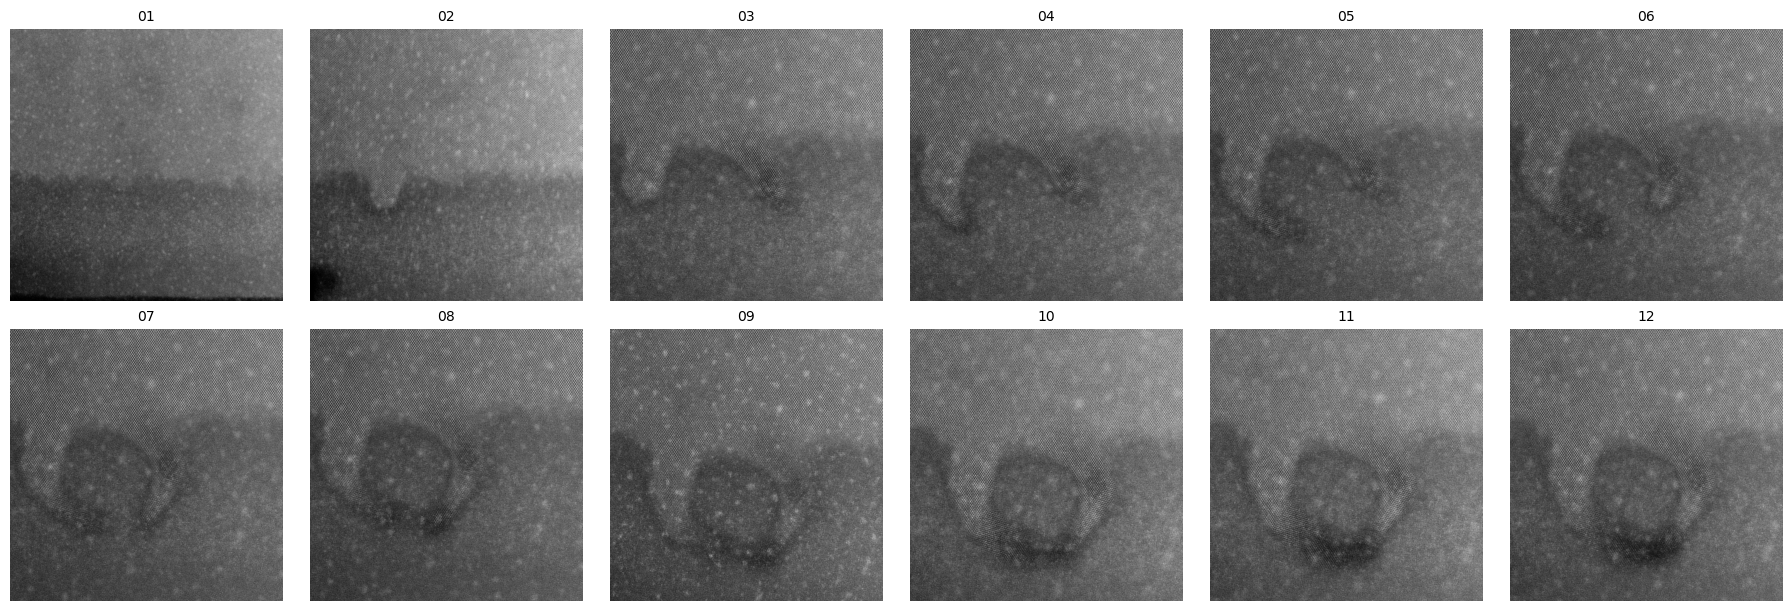

In [10]:
show_image_grid(
    sisb_images,
    titles=sisb_titles,
    rows=2,
)

### Human ground truth

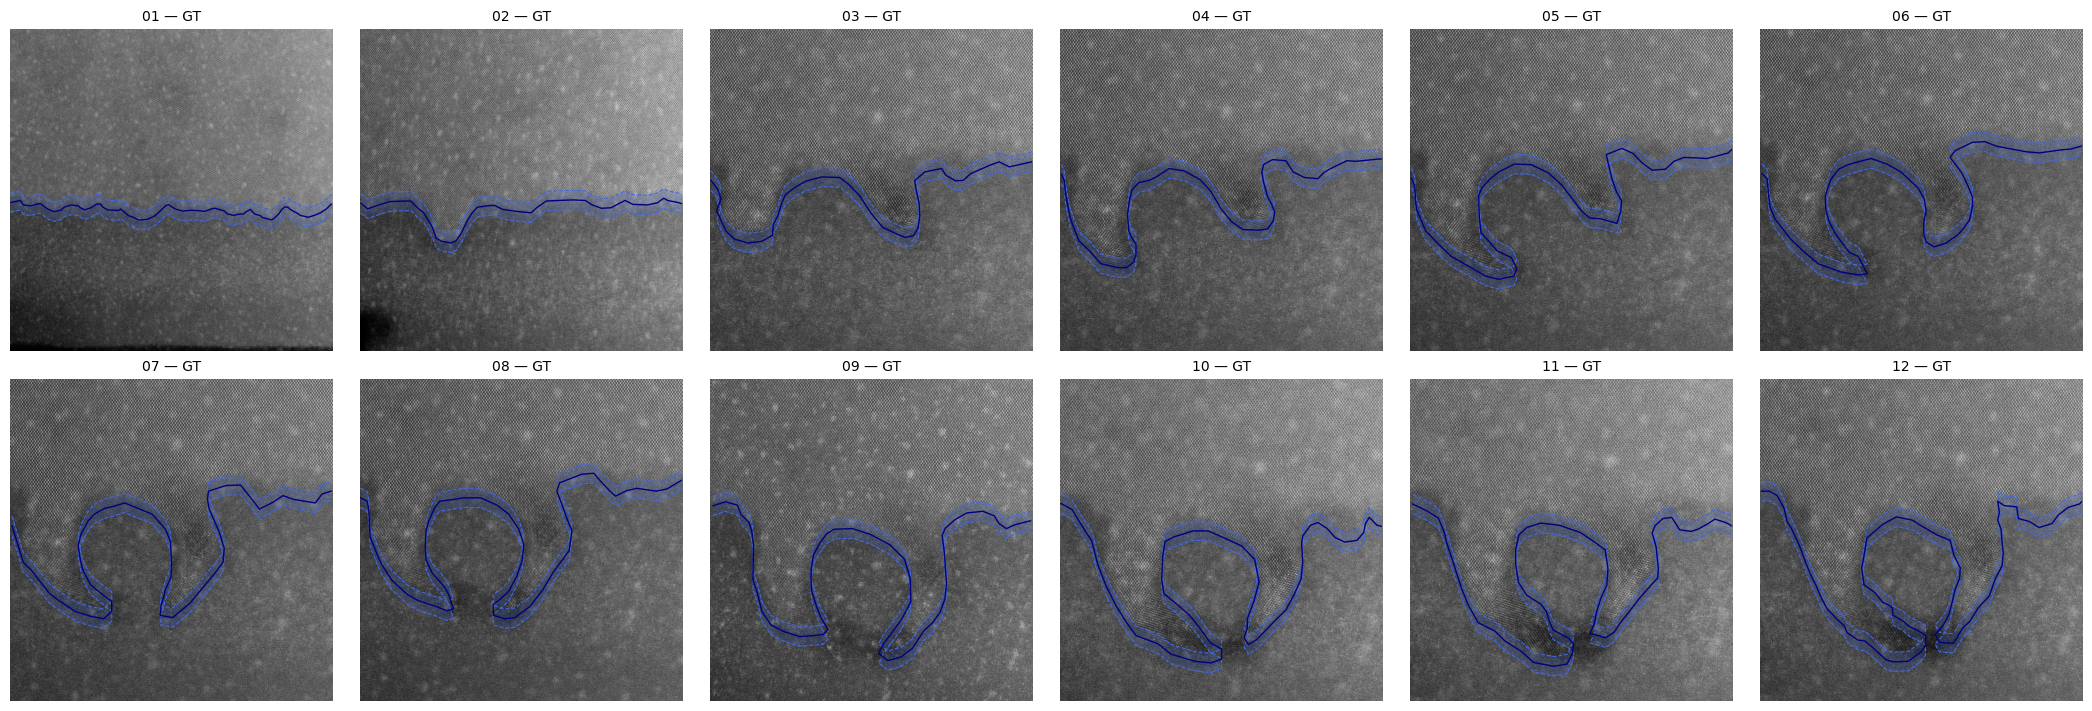

In [11]:
plot_ground_truth_grid(
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    rows=2,
)

## 3. Build your boundary detector

A simple texture-based baseline is provided.

You may completely replace the code between the two markers.  
Do **not** change the function name, input, or required output format.

In [12]:
def detect_boundary(image):
    import numpy as np
    from scipy import ndimage
    from skimage.morphology import remove_small_holes, remove_small_objects
    from skimage.measure import find_contours
    from skimage.draw import line as draw_line

    # ============================================================
    # 1. NORMALIZE + REMOVE SLOW BACKGROUND
    # ============================================================
    x = robust_normalize(image).astype(float)

    h, w = x.shape

    bg_sigma = max(15.0, min(h, w) / 20.0)

    background = ndimage.gaussian_filter(
        x,
        sigma=bg_sigma
    )

    flat = x - background

    # ============================================================
    # 2. USE TOP CRYSTALLINE REGION TO FIND BRAGG PEAKS
    # ============================================================
    roi_h = max(64, int(0.30 * h))
    roi = flat[:roi_h, :]

    rh, rw = roi.shape

    # Window to avoid FFT edge artifacts
    wy = np.hanning(rh)
    wx = np.hanning(rw)

    window = wy[:, None] * wx[None, :]

    F = np.fft.fftshift(
        np.fft.fft2(roi * window)
    )

    power = np.abs(F) ** 2

    # FFT frequency coordinates
    fy = np.fft.fftshift(
        np.fft.fftfreq(rh)
    )

    fx = np.fft.fftshift(
        np.fft.fftfreq(rw)
    )

    FX, FY = np.meshgrid(fx, fy)

    R = np.sqrt(
        FX**2 + FY**2
    )

    # ============================================================
    # 3. KEEP PHYSICALLY REASONABLE LATTICE FREQUENCIES
    # ============================================================

    # Corresponds approximately to lattice spacing 2.5–12 pixels
    f_min = 1.0 / 12.0
    f_max = 1.0 / 2.5

    allowed = (
        (R >= f_min)
        & (R <= f_max)
    )

    # ============================================================
    # 4. RADIAL WHITENING
    # ============================================================
    # Helps distinguish sharp Bragg peaks from broad amorphous
    # Fourier intensity.

    rr = R * min(rh, rw)

    rbin = np.floor(rr).astype(int)

    radial_background = np.zeros_like(power)

    for k in np.unique(rbin[allowed]):

        m = (rbin == k) & allowed

        if np.any(m):

            radial_background[m] = np.median(
                power[m]
            )

    whitened = power / (
        radial_background + 1e-12
    )

    whitened[~allowed] = 0.0

    whitened_s = ndimage.gaussian_filter(
        whitened,
        sigma=1.0
    )

    # ============================================================
    # 5. FIND CANDIDATE BRAGG PEAKS
    # ============================================================
    local_max = ndimage.maximum_filter(
        whitened_s,
        size=7,
        mode="nearest"
    )

    peak_mask = (
        allowed
        & (whitened_s == local_max)
    )

    py, px = np.nonzero(peak_mask)

    peak_strength = whitened_s[
        py,
        px
    ]

    order = np.argsort(
        peak_strength
    )[::-1]

    # ============================================================
    # 6. SELECT TWO NON-PARALLEL BRAGG VECTORS
    # ============================================================
    bragg_vectors = []

    for idx in order:

        gy = FY[py[idx], px[idx]]
        gx = FX[py[idx], px[idx]]

        gnorm = np.hypot(
            gx,
            gy
        )

        if gnorm == 0:
            continue

        accept = True

        for gx0, gy0 in bragg_vectors:

            cosang = abs(
                gx * gx0 + gy * gy0
            ) / (
                np.hypot(gx, gy)
                * np.hypot(gx0, gy0)
                + 1e-12
            )

            # Same or opposite Bragg direction
            if cosang > 0.92:
                accept = False
                break

        if accept:
            bragg_vectors.append(
                (gx, gy)
            )

        if len(bragg_vectors) == 2:
            break

    if len(bragg_vectors) == 0:
        return np.zeros_like(
            image,
            dtype=bool
        )

    # ============================================================
    # 7. CALCULATE LOCAL BRAGG COHERENCE
    # ============================================================

    Y, X = np.indices(
        (h, w)
    )

    coherence_maps = []

    for gx, gy in bragg_vectors:

        gmag = np.hypot(
            gx,
            gy
        )

        spacing = 1.0 / gmag

        # Smaller than previous 1.5 value:
        # sharper boundary localization
        sigma_coh = np.clip(
            1.2 * spacing,
            3.0,
            9.0
        )

        # Remove expected lattice oscillation
        phase = np.exp(
            -2j
            * np.pi
            * (
                gx * X
                + gy * Y
            )
        )

        demod = flat * phase

        zr = ndimage.gaussian_filter(
            demod.real,
            sigma=sigma_coh
        )

        zi = ndimage.gaussian_filter(
            demod.imag,
            sigma=sigma_coh
        )

        amplitude = np.sqrt(
            zr**2
            + zi**2
        )

        # Normalize by local RMS intensity
        local_energy = ndimage.gaussian_filter(
            flat**2,
            sigma=sigma_coh
        )

        local_rms = np.sqrt(
            np.maximum(
                local_energy,
                1e-12
            )
        )

        coherence = amplitude / (
            local_rms + 1e-12
        )

        coherence_maps.append(
            coherence
        )

    # ============================================================
    # 8. COMBINE THE TWO BRAGG DIRECTIONS
    # ============================================================

    if len(coherence_maps) == 1:

        score = coherence_maps[0]

    else:

        score = np.sqrt(
            coherence_maps[0]
            * coherence_maps[1]
        )

    # Very mild smoothing
    score = ndimage.gaussian_filter(
        score,
        sigma=1.0
    )

    # ============================================================
    # 9. TWO-THRESHOLD HYSTERESIS
    # ============================================================
    #
    # Top = known crystalline reference
    # Bottom = known amorphous reference
    #

    top_ref = score[
        int(0.05*h):
        int(0.20*h),
        :
    ]

    bottom_ref = score[
        int(0.80*h):
        int(0.95*h),
        :
    ]

    crystal_level = np.median(
        top_ref
    )

    amorphous_level = np.median(
        bottom_ref
    )

    # If direction somehow became reversed
    if crystal_level < amorphous_level:

        score_use = -score

        crystal_level = np.median(
            -top_ref
        )

        amorphous_level = np.median(
            -bottom_ref
        )

    else:

        score_use = score

    delta = (
        crystal_level
        - amorphous_level
    )

    # Low threshold:
    # "possibly crystalline"
    low_t = (
        amorphous_level
        + 0.30 * delta
    )

    # High threshold:
    # "definitely crystalline"
    high_t = (
        amorphous_level
        + 0.60 * delta
    )

    weak_crystal = (
        score_use > low_t
    )

    strong_crystal = (
        score_use > high_t
    )

    # ============================================================
    # 10. CONNECTIVITY / REGION GROWING
    # ============================================================
    #
    # Start only from strongly crystalline pixels near the top.
    # Then allow crystal to grow through weaker but plausible
    # crystalline pixels.
    #

    seed = np.zeros_like(
        strong_crystal,
        dtype=bool
    )

    seed_depth = max(
        3,
        int(0.10 * h)
    )

    seed[
        :seed_depth,
        :
    ] = strong_crystal[
        :seed_depth,
        :
    ]

    crystal_connected = (
        ndimage.binary_propagation(
            seed,
            mask=weak_crystal
        )
    )

    # ============================================================
    # 11. REMOVE SMALL ISLANDS AND HOLES
    # ============================================================

    small_area = max(
        20,
        int(0.0005 * h * w)
    )

    crystal_connected = remove_small_objects(
        crystal_connected,
        min_size=small_area
    )

    crystal_connected = remove_small_holes(
        crystal_connected,
        area_threshold=small_area
    )

    crystal_connected = ndimage.binary_closing(
        crystal_connected,
        structure=np.ones((3, 3)),
        iterations=1
    )

    # ============================================================
    # 12. SMOOTH ONLY THE FINAL INTERFACE GEOMETRY
    # ============================================================

    inside_distance = (
        ndimage.distance_transform_edt(
            crystal_connected
        )
    )

    outside_distance = (
        ndimage.distance_transform_edt(
            ~crystal_connected
        )
    )

    signed_distance = (
        inside_distance
        - outside_distance
    )

    signed_distance = ndimage.gaussian_filter(
        signed_distance,
        sigma=1.2
    )

    # ============================================================
    # 13. FIND FINAL ZERO-LEVEL CONTOUR
    # ============================================================

    contours = find_contours(
        signed_distance,
        level=0.0
    )

    boundary = np.zeros(
        image.shape,
        dtype=bool
    )

    for contour in contours:

        pts = np.round(
            contour
        ).astype(int)

        pts[:, 0] = np.clip(
            pts[:, 0],
            0,
            h - 1
        )

        pts[:, 1] = np.clip(
            pts[:, 1],
            0,
            w - 1
        )

        for (
            r0, c0
        ), (
            r1, c1
        ) in zip(
            pts[:-1],
            pts[1:]
        ):

            rr_line, cc_line = draw_line(
                r0,
                c0,
                r1,
                c1
            )

            boundary[
                rr_line,
                cc_line
            ] = True

    # ============================================================
    # 14. REMOVE IMAGE-BORDER ARTIFACTS
    # ============================================================

    margin = 3

    boundary[
        :margin,
        :
    ] = False

    boundary[
        -margin:,
        :
    ] = False

    boundary[
        :,
        :margin
    ] = False

    boundary[
        :,
        -margin:
    ] = False

    return boundary.astype(bool)

In [13]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def plot_gt_and_prediction_grid(
    images,
    files,
    titles,
    gt_dir,
    detector,
    rows=2,
):
    """
    Plot original images with:
      green  = ground truth
      yellow = prediction
    """

    n = len(images)
    cols = int(np.ceil(n / rows))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows)
    )

    axes = np.asarray(axes).reshape(-1)

    for i, (image, file, title) in enumerate(
        zip(images, files, titles)
    ):
        ax = axes[i]

        # ---------------------------------------------
        # Prediction from your code
        # ---------------------------------------------
        pred = detector(image)

        # ---------------------------------------------
        # Find corresponding GT file
        # Assumes GT is stored as .npy with same stem
        # ---------------------------------------------
        gt_file = Path(gt_dir) / f"{file.stem}.npy"

        if gt_file.exists():
            gt = np.load(gt_file).astype(bool)
        else:
            gt = None

        # ---------------------------------------------
        # Plot image
        # ---------------------------------------------
        ax.imshow(
            image,
            cmap="gray"
        )

        # Ground truth = green
        if gt is not None:
            yy, xx = np.nonzero(gt)

            ax.scatter(
                xx,
                yy,
                s=2,
                c="lime",
                label="Ground truth"
            )

        # Prediction = yellow
        yy, xx = np.nonzero(pred)

        ax.scatter(
            xx,
            yy,
            s=2,
            c="yellow",
            label="Prediction"
        )

        ax.set_title(title)
        ax.axis("off")

    # Hide unused panels
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # One common legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()

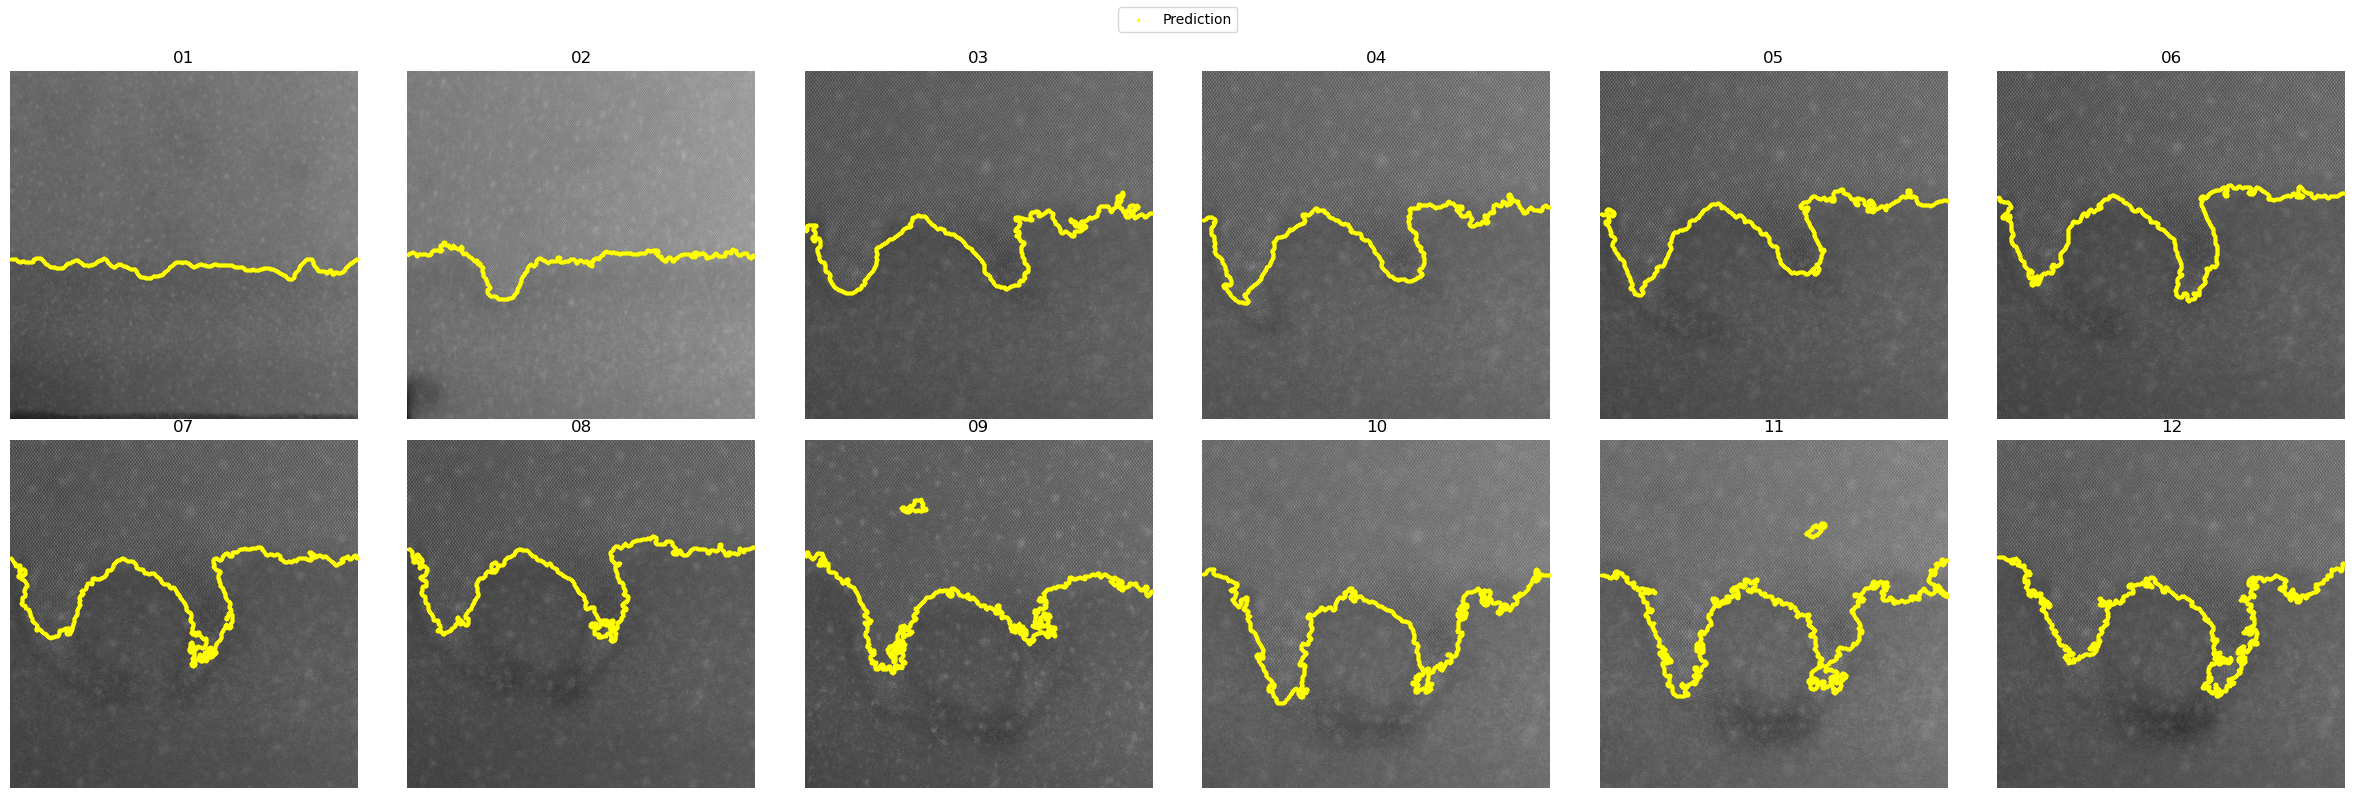

In [14]:
plot_gt_and_prediction_grid(
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    detect_boundary,
    rows=2,
)

## 4. Test one image visually

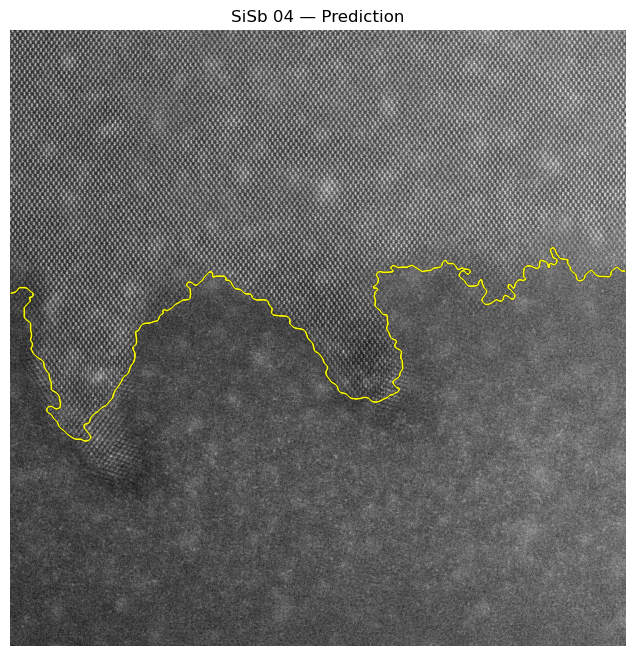

In [15]:
example_index = 3

image = sisb_images[example_index]
boundary = detect_boundary(image)

plot_boundary_result(
    image,
    boundary,
    title=f"SiSb {sisb_titles[example_index]} — Prediction",
)

## 5. Challenge 1 evaluation

We evaluate only three things:

### 1. Accuracy against human ground truth
Predictions are compared with the hand-drawn boundary using a spatial tolerance. Exact single-pixel agreement is not required.

Primary metric: **F1 @ 5 px tolerance**

### 2. Robustness
The same detector is tested after controlled perturbations:
- Gaussian noise
- Gaussian blur
- brightness change
- contrast change
- inclined intensity background

Every perturbed prediction is compared with the **same human ground truth**.

### 3. Speed
Only `detect_boundary(image)` is timed. File loading, plotting, and scoring are excluded.

### Test 1 — Accuracy against ground truth

In [14]:
accuracy_results = evaluate_against_ground_truth(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=10,
)

accuracy_results

,image,precision,recall,f1,mean_pred_to_gt_distance,mean_gt_to_pred_distance,mean_symmetric_boundary_error
0,01,0.675897,0.654966,0.665267,7.919873,8.188227,8.054050
1,02,0.156958,0.191519,0.172525,28.851794,23.436061,26.143927
2,03,0.091587,0.116703,0.102630,45.997476,35.518612,40.758044
3,04,0.015250,0.016702,0.015943,54.328166,61.321677,57.824921
4,05,0.049840,0.053250,0.051489,56.515381,102.675631,79.595506
5,06,0.037494,0.038613,0.038046,52.109614,98.441561,75.275587
6,07,0.000000,0.000000,0.000000,70.683538,111.847918,91.265728
7,08,0.022774,0.022449,0.022610,57.696693,124.374923,91.035808
8,09,0.014142,0.015478,0.014780,100.357576,164.712620,132.535098
9,10,0.089206,0.093295,0.091205,49.399620,96.103072,72.751346


In [15]:
summarize_accuracy(
    accuracy_results
)

mean_precision             0.114978
mean_recall                0.125018
mean_f1                    0.119267
mean_boundary_error_px    69.621423
Name: Clean boundary accuracy, dtype: float64

### Test 2 — Robustness

In [16]:
robustness_results = evaluate_robustness(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=5,
    max_images=4,
)

robustness_summary = summarize_robustness(
    robustness_results
)

robustness_summary

,condition,mean_f1,std_f1,mean_precision,mean_recall,mean_boundary_error_px,f1_drop_from_clean
0,Clean,0.120593,0.180445,0.124788,0.117394,57.891727,0.000000
1,Gaussian noise 5%,0.107398,0.176069,0.113653,0.101894,61.152873,0.013195
2,Gaussian blur sigma=1,0.148786,0.178916,0.149212,0.150861,51.945318,-0.028193
3,Brightness +10%,0.120593,0.180445,0.124788,0.117394,57.891727,0.000000
4,Contrast -20%,0.120593,0.180445,0.124788,0.117394,57.891727,0.000000
5,Intensity gradient 20%,0.120385,0.180773,0.124829,0.116869,57.978943,0.000208


Interpretation:

- `mean_f1`: accuracy under that condition
- `mean_boundary_error_px`: average symmetric distance to the human boundary
- `f1_drop_from_clean`: performance lost relative to the clean images

**Smaller F1 drop is better.**

### Test 3 — Speed

In [17]:
speed_results = evaluate_speed(
    detect_boundary,
    sisb_images,
    repeats=5,
)

summarize_speed(
    speed_results
)

mean_seconds_per_image      19.526728
median_seconds_per_image    19.718487
slowest_seconds             20.949446
images_per_second            0.051212
Name: Speed, dtype: float64

# Challenge 2 — Atom Finding in YBCO

## Goal

Write:

```python
positions = find_atoms(image)
```

The function must return a NumPy array of shape `(N, 2)`.

Each row is:

```text
[y, x]
```

in pixel coordinates.

## 6. Load YBCO

In [ ]:
ybco_files = list_emd_files(YBCO_DIR)

ybco_images = [
    load_haadf(file)
    for file in ybco_files
]

ybco_titles = [
    file.stem
    for file in ybco_files
]

print(f"Found {len(ybco_images)} YBCO images")

if ybco_images:
    show_image_grid(
        ybco_images,
        titles=[
            str(i + 1)
            for i in range(len(ybco_images))
        ],
        rows=1 if len(ybco_images) > 1 else 1,
    )

## 7. Build your atom finder

A simple local-maximum baseline is provided.

You may completely replace the code between the two markers.

In [ ]:
def find_atoms(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Smooth
    smooth = ndimage.gaussian_filter(
        x,
        sigma=1.0
    )

    # 3. Find local maxima
    neighborhood = 5

    local_max = (
        smooth
        == ndimage.maximum_filter(
            smooth,
            size=neighborhood,
            mode="reflect",
        )
    )

    # 4. Keep only bright maxima
    intensity_threshold = np.percentile(
        smooth,
        97.0,
    )

    peaks = (
        local_max
        & (smooth >= intensity_threshold)
    )

    # 5. Convert peaks to [y, x]
    positions = np.argwhere(peaks)

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return np.asarray(
        positions
    ).reshape(-1, 2).astype(float)

## 8. Test one YBCO image visually

In [ ]:
if ybco_images:

    atom_example_index = 0

    atom_positions = find_atoms(
        ybco_images[atom_example_index]
    )

    validate_atom_output(
        ybco_images[atom_example_index],
        atom_positions,
    )

    plot_atom_result(
        ybco_images[atom_example_index],
        atom_positions,
        title="YBCO atom finding",
    )

## 9. Challenge 2 engineering tests

Until atom ground truth is added, these measure **consistency and robustness**, not true atom-detection accuracy.

In [ ]:
if ybco_images:
    atom_noise_results = atom_noise_robustness(
        find_atoms,
        ybco_images,
        noise_levels=(0.01, 0.03, 0.05, 0.10),
        tolerance=2.0,
    )

atom_noise_results

In [ ]:
if ybco_images:
    atom_photometric_results = atom_photometric_robustness(
        find_atoms,
        ybco_images,
        tolerance=2.0,
    )

atom_photometric_results

In [ ]:
if ybco_images:

    atom_speed_results = evaluate_speed(
        find_atoms,
        ybco_images,
        repeats=5,
    )

summarize_speed(
        atom_speed_results
    )

# 10. Reflection

At the end of the session, be ready to explain:

1. What approach did you use?
2. Which parameters matter most?
3. Where does it fail?
4. What would you improve next?
5. If AI helped write code, what did it generate?
6. What did you personally change?

> A good scientific algorithm is not just one that gives a nice picture.  
> You should be able to explain **how accurate, robust, and fast it is**.

In [ ]:
# 10. Reflection

At the end of the session, be ready to explain:

1. What approach did you use?
I used a Bragg-coherence + connectivity method. The code finds Bragg peaks from a known crystalline region, measures how strongly each pixel follows
those lattice periodicities, then uses hysteresis and connectivity to keep only the crystal connected to the main crystalline region.
2. Which parameters matter most?
The most important parameters are the allowed lattice-frequency range, the coherence-window size sigma_coh, the low/high hysteresis thresholds, and
the size of the top crystalline seed region.
3. Where does it fail?
It can fail where the crystal near the interface has a different local orientation, strong strain, defects, or weak contrast. In those regions, the
fixed Bragg directions may give a low coherence score even though the material is still crystalline.
4. What would you improve next?
I would make the Bragg detection orientation-adaptive, so secondary crystal orientations are detected automatically instead of assuming one lattice
orientation everywhere.
5. If AI helped write code, what did it generate?
AI helped generate the Python implementation for FFT-based Bragg peak detection, local coherence calculation, hysteresis thresholding, connectivity
filtering, cleanup, and final contour extraction.
6. What did you personally change?
I selected the method based on the image behavior, tested the predictions, identified the failure regions, and adjusted the physical assumptions
and parameters based on what the actual crystal–amorphous boundary looked like.

> A good scientific algorithm is not just one that gives a nice picture.  
> You should be able to explain **how accurate, robust, and fast it is**.